# Sentiment Analysis (NLP): Using GCP annd Gemini models
## Overview, Objectives and techniques:
1. Customers comments are used to analyse data.
2. Data imported in csv format.
3. Data is stored in GCP storage bucket. And read into this accordingly.
4. Model gemini-2.0-flash-001 is used to get sentiments
5. NLP techniques of data cleaning, standardization, case normalization, stopwords are used.
6. Plot the sentiments between -1 and +1.
7. Summary.

### Costs

This tutorial uses billable components of Google Cloud:

- Vertex AI



## Getting Started

### Install Google Gen AI SDK for Python

In [1]:
%pip install --upgrade --quiet google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 732.2/732.2 kB 22.3 MB/s eta 0:00:00


### Restart current runtime

To use the newly installed packages in this Jupyter runtime, you must restart the runtime. You can do this by running the cell below, which will restart the current kernel.

In [2]:
# Restart kernel after installs so that your environment can access the new packages
import IPython

app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

<div class="alert alert-block alert-warning">
<b>⚠️ The kernel is going to restart. Please wait until it is finished before continuing to the next step. ⚠️</b>
</div>

### Authenticate your notebook environment (Colab only)

If you are running this notebook on Google Colab, run the following cell to authenticate your environment. This step is not required if you are using [Vertex AI Workbench](https://cloud.google.com/vertex-ai-workbench).

In [1]:
import sys

# Additional authentication is required for Google Colab
if "google.colab" in sys.modules:
    # Authenticate user to Google Cloud
    from google.colab import auth

    auth.authenticate_user()

#### Create a client for Vertex AI (with all Google Cloud capabilities and services)

Specify the project ID and location while creating the client.

In [2]:
import os

from google import genai

PROJECT_ID = "[your-project-id]"  # @param {type: "string", placeholder: "[your-project-id]", isTemplate: true}
if not PROJECT_ID or PROJECT_ID == "[your-project-id]":
    PROJECT_ID = str(os.environ.get("GOOGLE_CLOUD_PROJECT"))

LOCATION = os.environ.get("GOOGLE_CLOUD_REGION", "us-central1")

client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)

### Import libraries

In [3]:
from IPython.display import Markdown, display
from google.genai.types import GenerateContentConfig, Part

### Load Gemini 2.0 Flash model

Learn more about all [Gemini models on Vertex AI](https://cloud.google.com/vertex-ai/generative-ai/docs/learn/models#gemini-models).

In [4]:
MODEL_ID = "gemini-2.0-flash-001"  # @param {type: "string"}

In [10]:
# Load data from GCP cloud Storage
import pandas as pd

data = pd.read_csv("gs://rohith_data/data.csv")

print(data)

   Customer                                           Comments
0      C001  The GeoSolutions technology will leverage Bene...
1      C002  $ESI on lows, down $1.50 to $2.50 BK a real po...
2      C003  For the last quarter of 2010 , Componenta 's n...
3      C004  According to the Finnish-Russian Chamber of Co...
4      C005  The Swedish buyout firm has sold its remaining...
..      ...                                                ...
95     C096  M-Real said there are ` no grounds ' for the r...
96     C097  Lember said the matter was topical also in Est...
97     C098  - Moody 's said it gave P A1 long-term senior ...
98     C099                                       $TSLA recall
99     C100  The liquidity providing was interrupted on May...

[100 rows x 2 columns]


# Data Cleaning:
Removing Unwanted Characters (HTML, URLs, Special Characters)
Regular expressions (re library) are effective for removing specific patterns like HTML tags and URLs

In [12]:
import re

def clean_text(text):
    # Remove HTML tags
    text = re.sub('<.*?>+', '', text)
    # Remove URLs and email addresses
    text = re.sub(r'http\S+|www\S+|[\w.-]+@[\w.-]+', '', text, flags=re.MULTILINE)
    # Remove special characters and numbers (keep letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text, flags=re.MULTILINE)
    # Remove extra whitespace
    text = re.sub(' +', ' ', text)
    return text

# Apply the function to a column in a DataFrame
data['cleaned_comments'] = data['Comments'].apply(clean_text)


3. Case Standardization
Converting all text to a consistent case (usually lowercase) helps treat words like "Run" and "run" as the same

In [14]:
data['cleaned_comments'] = data['cleaned_comments'].apply(lambda x: x.lower())


4. Removing Stopwords

Stopwords (e.g., "a", "the", "is") are common words that often provide little value for model training and can be removed using libraries like NLTK.

In [16]:
import nltk
from nltk.corpus import stopwords

# Download stopwords list if not already available
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    # Tokenize the text (split into words) and remove stopwords
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

data['cleaned_comments'] = data['cleaned_comments'].apply(remove_stopwords)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
data = data[['Customer', 'cleaned_comments']]
print(data)

   Customer                                   cleaned_comments
0      C001  geosolutions technology leverage benefon gps s...
1      C002                       esi lows bk real possibility
2      C003  last quarter componenta net sales doubled eurm...
3      C004  according finnishrussian chamber commerce majo...
4      C005  swedish buyout firm sold remaining percent sta...
..      ...                                                ...
95     C096  mreal said grounds rumors circulating market m...
96     C097  lember said matter topical also estonia bill d...
97     C098  moody said gave p longterm senior unsecured p ...
98     C099                                        tsla recall
99     C100  liquidity providing interrupted may aspocomp g...

[100 rows x 2 columns]


In [20]:
print(data)

   Customer                                   cleaned_comments
0      C001  geosolutions technology leverage benefon gps s...
1      C002                       esi lows bk real possibility
2      C003  last quarter componenta net sales doubled eurm...
3      C004  according finnishrussian chamber commerce majo...
4      C005  swedish buyout firm sold remaining percent sta...
..      ...                                                ...
95     C096  mreal said grounds rumors circulating market m...
96     C097  lember said matter topical also estonia bill d...
97     C098  moody said gave p longterm senior unsecured p ...
98     C099                                        tsla recall
99     C100  liquidity providing interrupted may aspocomp g...

[100 rows x 2 columns]


### Run sentiment analysis on audio content

Now you can ask Gemini to run sentiment analysis directly on the audio file content.

In [21]:
sentiment_results = []
for index, row in data.iterrows():
    comment = row['cleaned_comments']
    customer_id = row['Customer']
    prompt = f"Provide a sentiment of the following comment. Give score for sentiment ranging from -1 (very negative) to +1 (very positive). Only return the score as a float.\n\nComment: {comment}"
    response = client.models.generate_content(
        model=MODEL_ID,
        contents=[
            prompt,
        ],
        config=GenerateContentConfig(
            temperature=0.0
        )
    )
    try:
        sentiment_score = float(response.text.strip())
        sentiment_results.append({'Customer': customer_id, 'Comment': comment, 'Sentiment_Score': sentiment_score})
    except ValueError:
        sentiment_results.append({'Customer': customer_id, 'Comment': comment, 'Sentiment_Score': 'N/A'})

sentiment_df = pd.DataFrame(sentiment_results)
display(sentiment_df)

,Customer,Comment,Sentiment_Score
0,C001,geosolutions technology leverage benefon gps s...,0.5
1,C002,esi lows bk real possibility,-0.7
2,C003,last quarter componenta net sales doubled eurm...,-0.3
3,C004,according finnishrussian chamber commerce majo...,0.0
4,C005,swedish buyout firm sold remaining percent sta...,-0.2
...,...,...,...
95,C096,mreal said grounds rumors circulating market m...,-0.2
96,C097,lember said matter topical also estonia bill d...,-0.3
97,C098,moody said gave p longterm senior unsecured p ...,-0.2
98,C099,tsla recall,-0.3


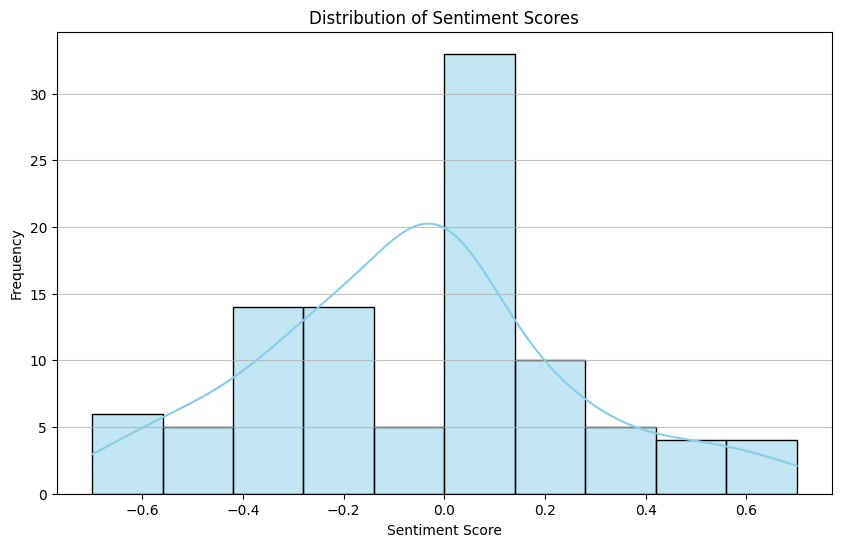

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(sentiment_df['Sentiment_Score'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [25]:
average_sentiment_score = sentiment_df['Sentiment_Score'].mean()
print(f"The average sentiment score is: {average_sentiment_score:.2f}")

The average sentiment score is: -0.06


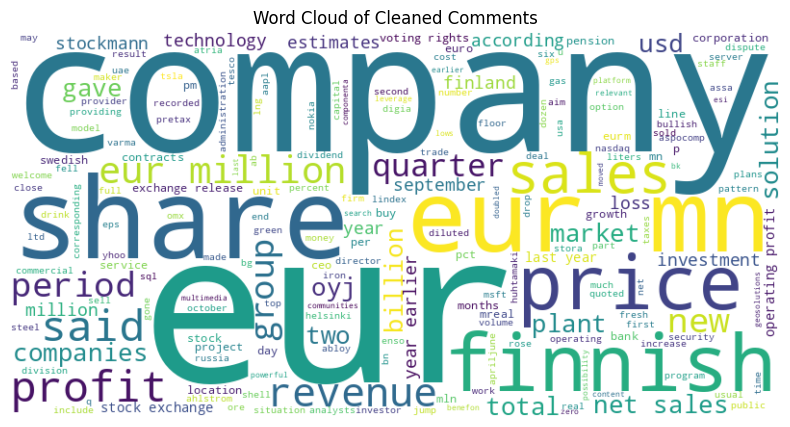

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned comments into a single string
all_comments = ' '.join(sentiment_df['Comment']).lower()

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_comments)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Comments')
plt.show()

**Summary of the analysis:**

The comments are imported from csv file.

Comment Categorization: The Gemini model to automatically categorize each cleaned comment based on its content, adding a new 'Category' column to our sentiment_df.

Categorized Sentiment Analysis: calculate the average sentiment score for each of these generated categories, allowing us to understand the general sentiment associated with different topics.

Visualizing Categorized Sentiment: A bar chart was created to visually represent the average sentiment score for each category, providing a clear overview of sentiment distribution across different themes in your data.



